In [19]:
import os
import json
import csv
import random 
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

from dataclasses import dataclass, asdict
from typing import List, Optional

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [3]:
def set_seed(seed: int=42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_full = torchvision.datasets.CIFAR10(
    root="./data", train = True, download = True, transform = transform
)
test_ds = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train size: 50000
test size: 10000


In [5]:
BATCH_SIZE = 256 if device.type == "cuda" else 64

NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 3, 32, 32]) torch.float32
y_batch: torch.Size([64]) torch.int64


In [16]:
def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 32 * 32 * 3,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=32*32*3,
            hidden_dims=(512, 256, 128),
            activation='relu',
            dropout_p=0.2,
            use_batchnorm=True).to(device)

with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 10])


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy(logits, y) * bs
        n += bs
    return total_loss / n, total_acc / n

In [9]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [14]:
@dataclass
class ExperimentConfig:
    name: str
    hidden_dims: List[int] = (512, 256, 128)
    activation: str = "relu"
    dropout_p: float = 0.0
    use_batchnorm: bool = False
    optimizer: str = "adam"
    lr: float = 1e-3
    momentum: float = 0.0
    weight_decay: float = 0.0
    epochs: int = 20
    early_stopping_patience: Optional[int] = None
    seed: int = 42
    dataset: str = "CIFAR10"

def run_experiment(cfg: ExperimentConfig, return_history=False):
    set_seed(cfg.seed)
    model = MLP(
        hidden_dims=cfg.hidden_dims,
        activation=cfg.activation,
        dropout_p=cfg.dropout_p,
        use_batchnorm=cfg.use_batchnorm
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    if cfg.optimizer.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=cfg.lr,
                              momentum=cfg.momentum, weight_decay=cfg.weight_decay)

    early_stopping = EarlyStopping(patience=cfg.early_stopping_patience) if cfg.early_stopping_patience else None

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = -1.0
    best_epoch = -1
    best_state = None

    for epoch in range(1, cfg.epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if early_stopping is not None:
            if early_stopping.step(val_acc, model):
                print(f"{cfg.name}: Early stopping at epoch {epoch}")
                break

    if early_stopping is not None:
        early_stopping.restore_best(model)
        best_val_acc = early_stopping.best_score

    if best_state is not None:
        model.load_state_dict(best_state)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    if return_history:
        return best_val_acc, best_epoch, test_acc, test_loss, history, model
    else:
        return best_val_acc, best_epoch, test_acc, test_loss, None

In [23]:
cfg_e1 = ExperimentConfig(
    name="E1_base",
    hidden_dims=[512, 256, 128],
    activation="relu",
    dropout_p=0.0,
    use_batchnorm=False,
    optimizer="adam",
    lr=1e-3,
    epochs=20,
    dataset="CIFAR10"
)

cfg_e2 = ExperimentConfig(
    name="E2_dropout",
    hidden_dims=[512, 256, 128],
    activation="relu",
    dropout_p=0.3,
    use_batchnorm=False,
    optimizer="adam",
    lr=1e-3,
    epochs=20,
    dataset="CIFAR10"
)

cfg_e3 = ExperimentConfig(
    name="E3_batchnorm",
    hidden_dims=[512, 256, 128],
    activation="relu",
    dropout_p=0.0,
    use_batchnorm=True,
    optimizer="adam",
    lr=1e-3,
    epochs=20,
    dataset="CIFAR10"
)

results = []

for cfg in [cfg_e1, cfg_e2, cfg_e3]:
    print(f"\nЗапуск {cfg.name}")
    best_val_acc, best_epoch, test_acc, test_loss, _ = run_experiment(cfg, return_history=False)
    results.append({
        "experiment_id": cfg.name,
        "dataset": cfg.dataset,
        "seed": cfg.seed,
        "model_summary": f"hidden={cfg.hidden_dims}, activation={cfg.activation}, dropout={cfg.dropout_p}, batchnorm={cfg.use_batchnorm}",
        "optimizer": cfg.optimizer,
        "lr": cfg.lr,
        "momentum": cfg.momentum,
        "weight_decay": cfg.weight_decay,
        "epochs_trained": cfg.epochs,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": None,
    })
    print(f"{cfg.name}: best_val_acc={best_val_acc:.4f} at epoch {best_epoch}, test_acc={test_acc:.4f}")

best_reg_name = max(results[1:], key=lambda x: x["best_val_accuracy"])["experiment_id"]
print(f"\nЛучший среди E2/E3: {best_reg_name}")

if best_reg_name == "E2_dropout":
    cfg_e4_base = cfg_e2
else:
    cfg_e4_base = cfg_e3

cfg_e4 = ExperimentConfig(
    name="E4_best+earlystop",
    hidden_dims=cfg_e4_base.hidden_dims,
    activation=cfg_e4_base.activation,
    dropout_p=cfg_e4_base.dropout_p,
    use_batchnorm=cfg_e4_base.use_batchnorm,
    optimizer=cfg_e4_base.optimizer,
    lr=cfg_e4_base.lr,
    epochs=50,
    early_stopping_patience=4,
    dataset=cfg_e4_base.dataset
)

print(f"\nЗапуск {cfg_e4.name} (лучшая регуляризация + EarlyStopping)")
best_val_acc, best_epoch, test_acc, test_loss, history_e4, best_model = run_experiment(cfg_e4, return_history=True)
results.append({
    "experiment_id": cfg_e4.name,
    "dataset": cfg_e4.dataset,
    "seed": cfg_e4.seed,
    "model_summary": f"hidden={cfg_e4.hidden_dims}, activation={cfg_e4.activation}, dropout={cfg_e4.dropout_p}, batchnorm={cfg_e4.use_batchnorm}",
    "optimizer": cfg_e4.optimizer,
    "lr": cfg_e4.lr,
    "momentum": cfg_e4.momentum,
    "weight_decay": cfg_e4.weight_decay,
    "epochs_trained": len(history_e4["train_loss"]),
    "best_val_accuracy": best_val_acc,
    "best_val_loss": None,
})
print(f"{cfg_e4.name}: best_val_acc={best_val_acc:.4f} at epoch {best_epoch}, test_acc={test_acc:.4f}")

torch.save(best_model.state_dict(), "./artifacts/best_model.pt")
print("Лучшая модель сохранена в artifacts/best_model.pt")

best_config = asdict(cfg_e4)
best_config["test_accuracy"] = test_acc
with open("./artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)
print("Конфиг лучшей модели сохранён в artifacts/best_config.json")


Запуск E1_base
E1_base: best_val_acc=0.5424 at epoch 9, test_acc=0.5351

Запуск E2_dropout
E2_dropout: best_val_acc=0.5362 at epoch 18, test_acc=0.5305

Запуск E3_batchnorm
E3_batchnorm: best_val_acc=0.5664 at epoch 11, test_acc=0.5594

Лучший среди E2/E3: E3_batchnorm

Запуск E4_best+earlystop (лучшая регуляризация + EarlyStopping)
E4_best+earlystop: Early stopping at epoch 15
E4_best+earlystop: best_val_acc=0.5664 at epoch 11, test_acc=0.5594
Лучшая модель сохранена в artifacts/best_model.pt
Конфиг лучшей модели сохранён в artifacts/best_config.json


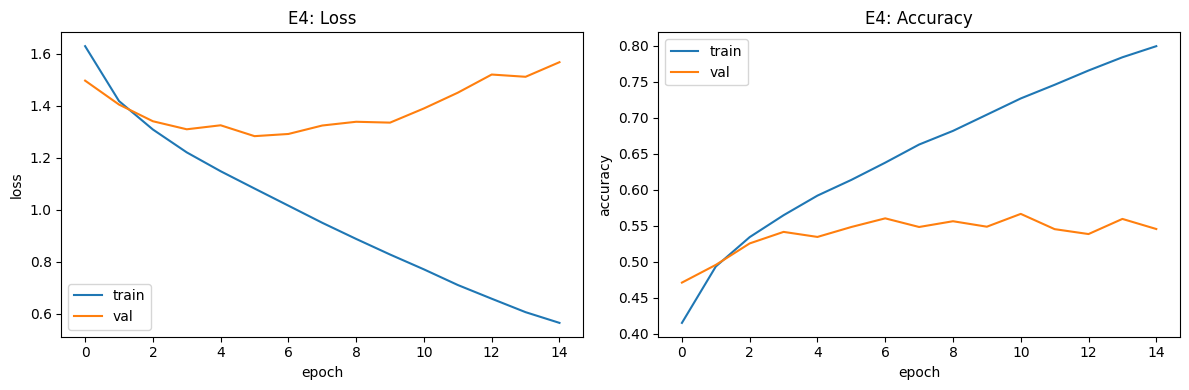

График лучшей модели сохранён в artifacts/figures/curves_best.png


In [20]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_e4["train_loss"], label="train")
plt.plot(history_e4["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("E4: Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_e4["train_acc"], label="train")
plt.plot(history_e4["val_acc"], label="val")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("E4: Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("./artifacts/figures/curves_best.png")
plt.show()
print("График лучшей модели сохранён в artifacts/figures/curves_best.png")

In [21]:
base_cfg_for_B = cfg_e4_base

cfg_o1 = ExperimentConfig(
    name="O1_lr_too_high",
    hidden_dims=base_cfg_for_B.hidden_dims,
    activation=base_cfg_for_B.activation,
    dropout_p=base_cfg_for_B.dropout_p,
    use_batchnorm=base_cfg_for_B.use_batchnorm,
    optimizer="adam",
    lr=1e-1,
    epochs=8,
    dataset="CIFAR10"
)

cfg_o2 = ExperimentConfig(
    name="O2_lr_too_low",
    hidden_dims=base_cfg_for_B.hidden_dims,
    activation=base_cfg_for_B.activation,
    dropout_p=base_cfg_for_B.dropout_p,
    use_batchnorm=base_cfg_for_B.use_batchnorm,
    optimizer="adam",
    lr=1e-5,
    epochs=8,
    dataset="CIFAR10"
)

cfg_o3 = ExperimentConfig(
    name="O3_sgd_mom_wd",
    hidden_dims=base_cfg_for_B.hidden_dims,
    activation=base_cfg_for_B.activation,
    dropout_p=base_cfg_for_B.dropout_p,
    use_batchnorm=base_cfg_for_B.use_batchnorm,
    optimizer="sgd",
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4,
    epochs=15,
    dataset="CIFAR10"
)

for cfg in [cfg_o1, cfg_o2, cfg_o3]:
    print(f"\nЗапуск {cfg.name}")
    best_val_acc, best_epoch, test_acc, test_loss, history, _ = run_experiment(cfg, return_history=True)
    results.append({
        "experiment_id": cfg.name,
        "dataset": cfg.dataset,
        "seed": cfg.seed,
        "model_summary": f"hidden={cfg.hidden_dims}, activation={cfg.activation}, dropout={cfg.dropout_p}, batchnorm={cfg.use_batchnorm}",
        "optimizer": cfg.optimizer,
        "lr": cfg.lr,
        "momentum": cfg.momentum if cfg.optimizer=="sgd" else 0.0,
        "weight_decay": cfg.weight_decay,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": None,
    })
    print(f"{cfg.name}: best_val_acc={best_val_acc:.4f} at epoch {best_epoch}, test_acc={test_acc:.4f}")

    if cfg.name == "O1_lr_too_high":
        hist_o1 = history
    if cfg.name == "O2_lr_too_low":
        hist_o2 = history


Запуск O1_lr_too_high
O1_lr_too_high: best_val_acc=0.5016 at epoch 6, test_acc=0.5006

Запуск O2_lr_too_low
O2_lr_too_low: best_val_acc=0.5218 at epoch 8, test_acc=0.5178

Запуск O3_sgd_mom_wd
O3_sgd_mom_wd: best_val_acc=0.5466 at epoch 12, test_acc=0.5462


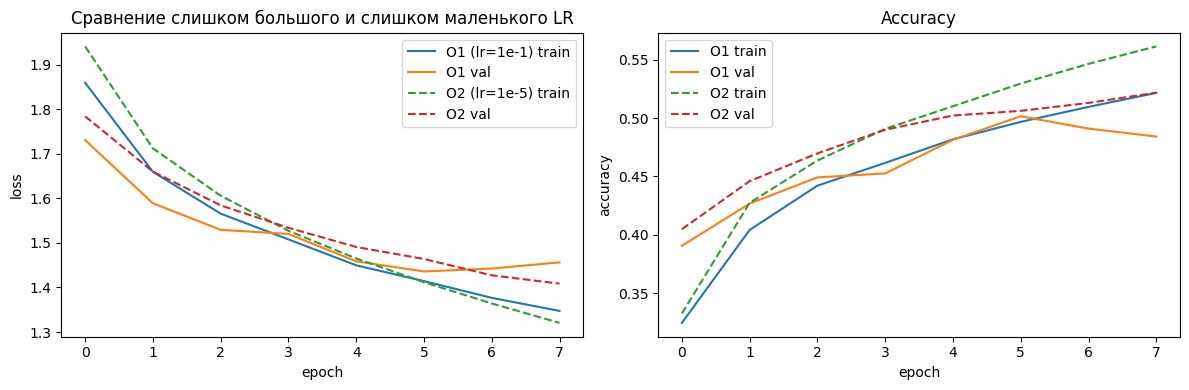

График экстремальных LR сохранён в artifacts/figures/curves_lr_extremes.png


In [22]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist_o1["train_loss"], label="O1 (lr=1e-1) train")
plt.plot(hist_o1["val_loss"], label="O1 val")
plt.plot(hist_o2["train_loss"], label="O2 (lr=1e-5) train", linestyle="--")
plt.plot(hist_o2["val_loss"], label="O2 val", linestyle="--")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Сравнение слишком большого и слишком маленького LR")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_o1["train_acc"], label="O1 train")
plt.plot(hist_o1["val_acc"], label="O1 val")
plt.plot(hist_o2["train_acc"], label="O2 train", linestyle="--")
plt.plot(hist_o2["val_acc"], label="O2 val", linestyle="--")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("./artifacts/figures/curves_lr_extremes.png")
plt.show()
print("График экстремальных LR сохранён в artifacts/figures/curves_lr_extremes.png")

In [24]:
csv_columns = ["experiment_id", "dataset", "seed", "model_summary", "optimizer", "lr", "momentum", "weight_decay", "epochs_trained", "best_val_accuracy", "best_val_loss"]
csv_path = "./artifacts/runs.csv"
with open(csv_path, mode="w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=csv_columns)
    writer.writeheader()
    for row in results:
        row = {k: (str(v) if isinstance(v, float) else v) for k, v in row.items()}
        writer.writerow(row)

print(f"Таблица результатов сохранена в {csv_path}")

Таблица результатов сохранена в ./artifacts/runs.csv
